In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [8]:
path = "/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"

In [9]:
df_orders = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv")
df_geolocation = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv")
df_products = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv")
df_sellers = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv")
df_product_category = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv")
df_customer = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv")

In [10]:
date_cols = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')
olist_df = (
    df_orders
    .merge(df_customer[['customer_id', 'customer_city', 'customer_state']], on='customer_id', how='left')
    .merge(df_order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']], on='order_id', how='left')
    .merge(df_order_payments[['order_id', 'payment_type', 'payment_value']], on='order_id', how='left')
    .merge(df_order_reviews[['order_id', 'review_score', 'review_comment_title', 'review_comment_message']], on='order_id', how='left')
    .merge(df_products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(df_product_category, on='product_category_name', how='left')
)

In [11]:
olist_df.rename(columns={'product_category_name_english': 'product_category_en'}, inplace=True)

olist_df['delivery_days'] = (olist_df['order_delivered_customer_date'] - olist_df['order_purchase_timestamp']).dt.days
olist_df['delivery_delay'] = (olist_df['order_delivered_customer_date'] - olist_df['order_estimated_delivery_date']).dt.days
olist_df['Total_price_value'] = olist_df['price'] + olist_df['freight_value']
olist_df['order_month'] = olist_df['order_purchase_timestamp'].dt.to_period("M")
olist_df['order_year'] = olist_df['order_purchase_timestamp'].dt.year
olist_df['freight_ratio'] = (olist_df['freight_value'] / olist_df['Total_price_value']) * 100
olist_df['delivery_performance'] = pd.cut(
    olist_df['delivery_delay'],
    bins=[-np.inf, 0, 7, 14, np.inf],
    labels=['On-Time', '1-7 Days Late', '8-14 Days Late', '>14 Days Late']
)

In [12]:
avg_score = olist_df.groupby('product_category_en')['review_score'].mean().reset_index()
avg_score.columns = ['category', 'avg_score']
print(avg_score.sort_values('avg_score', ascending=False).head(10))

                                 category  avg_score
11                      cds_dvds_musicals   4.642857
29              fashion_childrens_clothes   4.500000
8                  books_general_interest   4.438503
9                          books_imported   4.419355
35                                flowers   4.419355
22                costruction_tools_tools   4.415842
10                        books_technical   4.375465
37                             food_drink   4.324138
64  small_appliances_home_oven_and_coffee   4.320513
53                    luggage_accessories   4.295945


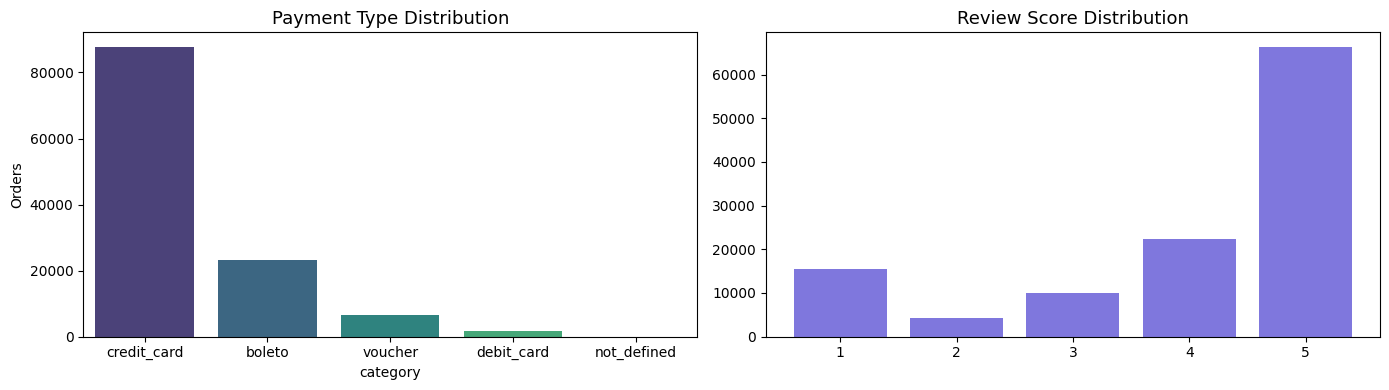

In [13]:
payment_dist = olist_df['payment_type'].value_counts().reset_index()
payment_dist.columns = ['category', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=payment_dist, x='category', y='count', palette='viridis', ax=axes[0], hue='category', legend=False)
axes[0].set_title('Payment Type Distribution', fontsize=13)
axes[0].set_ylabel('Orders')

review_counts = olist_df['review_score'].value_counts().sort_index()
axes[1].bar(review_counts.index, review_counts.values, color='#7F77DD')
axes[1].set_title('Review Score Distribution', fontsize=13)
plt.tight_layout()
plt.show()

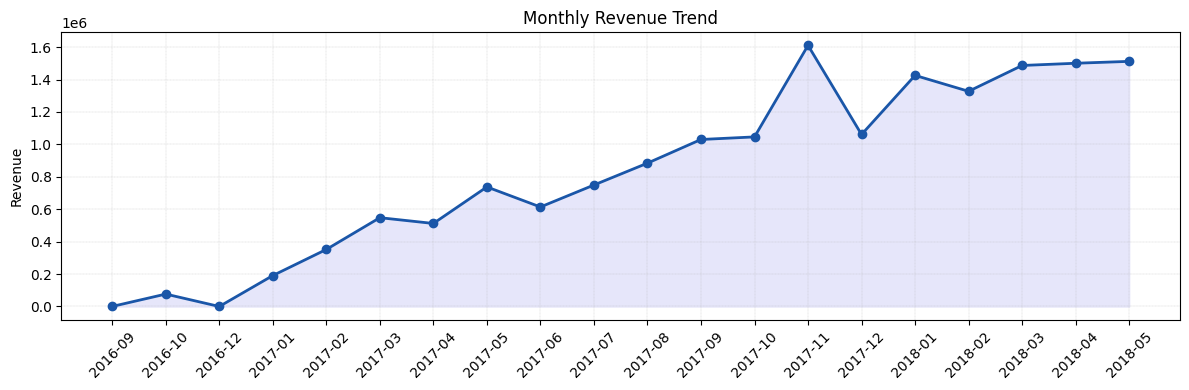

In [14]:
monthly_revenue = olist_df.groupby('order_month')['payment_value'].sum().reset_index().head(20)
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(monthly_revenue['order_month'], monthly_revenue['payment_value'], marker='o', linewidth=2, color='#1A56A8')
plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.fill_between(monthly_revenue['order_month'], monthly_revenue['payment_value'], color='#E6E6FA')
plt.grid(linestyle='--', linewidth=0.2)
plt.tight_layout()
plt.show()

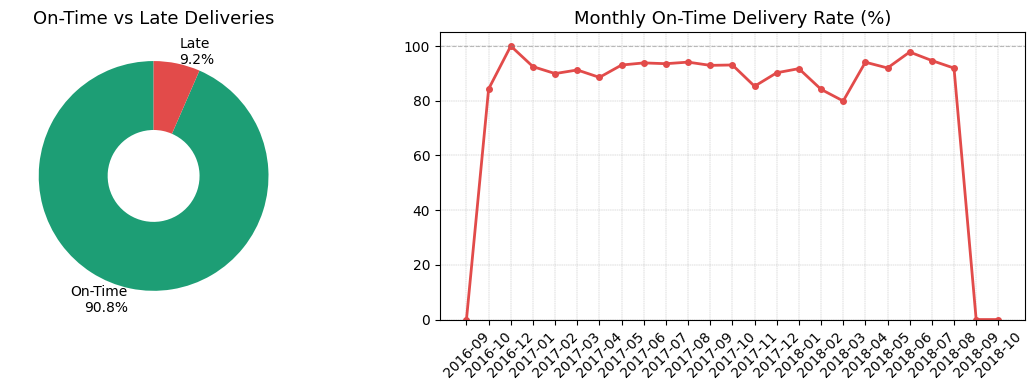

In [15]:
on_time = (olist_df['delivery_delay'] <= 0).sum()
late = (olist_df['delivery_delay'] > 0).sum()
total_del = len(olist_df['delivery_delay'])
on_time_rate = (on_time / total_del) * 100

monthly_ontime = olist_df.groupby('order_month').apply(
    lambda x: (x['delivery_delay'] <= 0).mean() * 100, include_groups=False
).reset_index()
monthly_ontime.columns = ['order_month', 'on_time_pct']
monthly_ontime['month_str'] = monthly_ontime['order_month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie([on_time, late],
            labels=[f"On-Time\n{on_time_rate:.1f}%", f"Late\n{100-on_time_rate:.1f}%"],
            colors=['#1D9E75', '#E24B4A'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[0].set_title('On-Time vs Late Deliveries', fontsize=13)

axes[1].plot(monthly_ontime['month_str'], monthly_ontime['on_time_pct'], color='#E24B4A', linewidth=2, marker='o', markersize=4)
axes[1].axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title('Monthly On-Time Delivery Rate (%)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 105)
plt.tight_layout()
plt.grid(linewidth=0.3, linestyle='--')
plt.show()

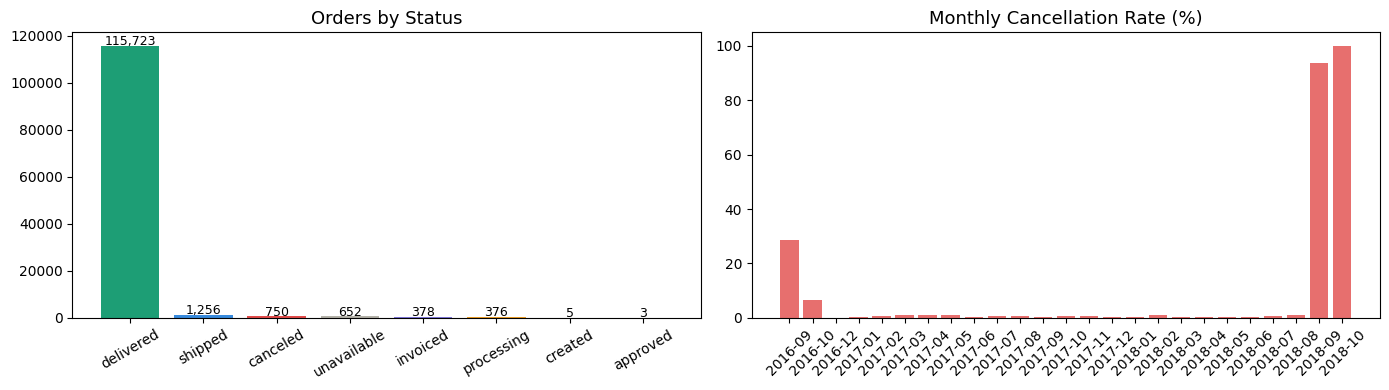

In [16]:
status_counts = olist_df['order_status'].value_counts()
monthly_cancel = olist_df.groupby('order_month').apply(
    lambda x: (x['order_status'] == 'canceled').mean() * 100, include_groups=False
).reset_index()
monthly_cancel.columns = ['month', 'cancel_pct']
monthly_cancel['month_str'] = monthly_cancel['month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors_map = {'delivered': '#1D9E75', 'shipped': '#378ADD', 'canceled': '#E24B4A', 'processing': '#EF9F27', 'invoiced': '#7F77DD', 'approved': '#5DCAA5', 'unavailable': '#B4B2A9'}
bar_colors = [colors_map.get(s, '#888780') for s in status_counts.index]

axes[0].bar(status_counts.index, status_counts.values, color=bar_colors)
axes[0].set_title('Orders by Status', fontsize=13)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(monthly_cancel['month_str'], monthly_cancel['cancel_pct'], color='#E24B4A', alpha=0.8)
axes[1].set_title('Monthly Cancellation Rate (%)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

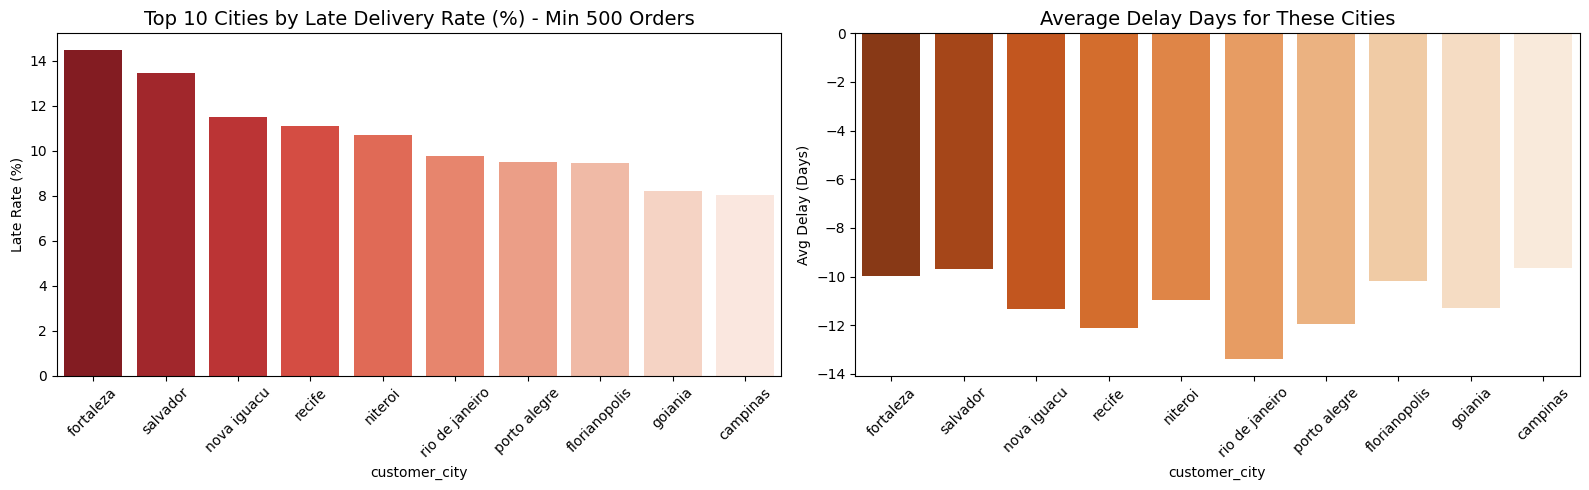

In [17]:
city_metrics = olist_df.groupby('customer_city').agg(
    total_orders=('order_id', 'count'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay=('delivery_delay', 'mean'),
    late_rate=('delivery_delay', lambda x: (x > 0).mean() * 100)
).reset_index()

valid_cities = city_metrics[city_metrics['total_orders'] >= 500]
worst_logistics_cities = valid_cities.sort_values('late_rate', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=worst_logistics_cities, x='customer_city', y='late_rate', palette='Reds_r', hue='customer_city', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Cities by Late Delivery Rate (%) - Min 500 Orders', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Late Rate (%)')

sns.barplot(data=worst_logistics_cities, x='customer_city', y='avg_delay', palette='Oranges_r', hue='customer_city', legend=False, ax=axes[1])
axes[1].set_title('Average Delay Days for These Cities', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Avg Delay (Days)')

plt.tight_layout()
plt.show()

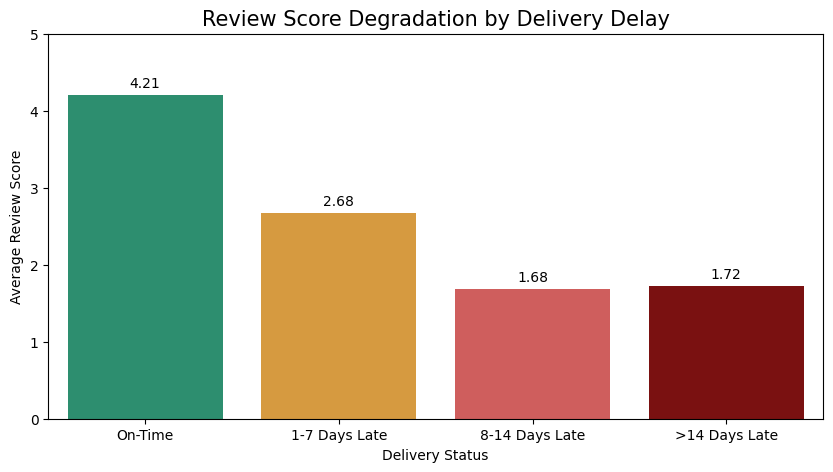

In [18]:
impact_analysis = olist_df.groupby('delivery_performance', observed=True).agg(
    avg_review_score=('review_score', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=impact_analysis, x='delivery_performance', y='avg_review_score', palette=['#1D9E75', '#EF9F27', '#E24B4A', '#8B0000'], hue='delivery_performance', legend=False)

for index, row in impact_analysis.iterrows():
    plt.text(index, row['avg_review_score'] + 0.1, f"{row['avg_review_score']:.2f}", color='black', ha="center")

plt.title('Review Score Degradation by Delivery Delay', fontsize=15)
plt.ylabel('Average Review Score')
plt.xlabel('Delivery Status')
plt.ylim(0, 5)
plt.show()

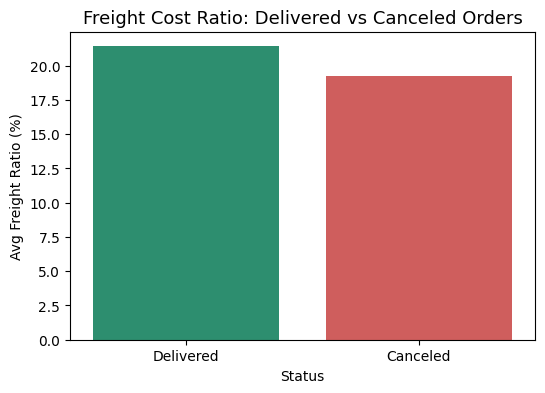

In [19]:
freight_impact = olist_df[olist_df['order_status'] == 'canceled'].copy()
baseline_freight = olist_df[olist_df['order_status'] == 'delivered']['freight_ratio'].mean()
canceled_freight = freight_impact['freight_ratio'].mean()

comparison_df = pd.DataFrame({
    'Status': ['Delivered', 'Canceled'],
    'Avg Freight Ratio (%)': [baseline_freight, canceled_freight]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=comparison_df, x='Status', y='Avg Freight Ratio (%)', palette=['#1D9E75', '#E24B4A'], hue='Status', legend=False)
plt.title('Freight Cost Ratio: Delivered vs Canceled Orders', fontsize=13)
plt.show()